## LAB WORK

DTW Distance: 9.0
Alignment Path: [(0, 0), (1, 0), (2, 1), (3, 2), (4, 3), (5, 4), (6, 5), (7, 6), (8, 7), (9, 8), (9, 9)]


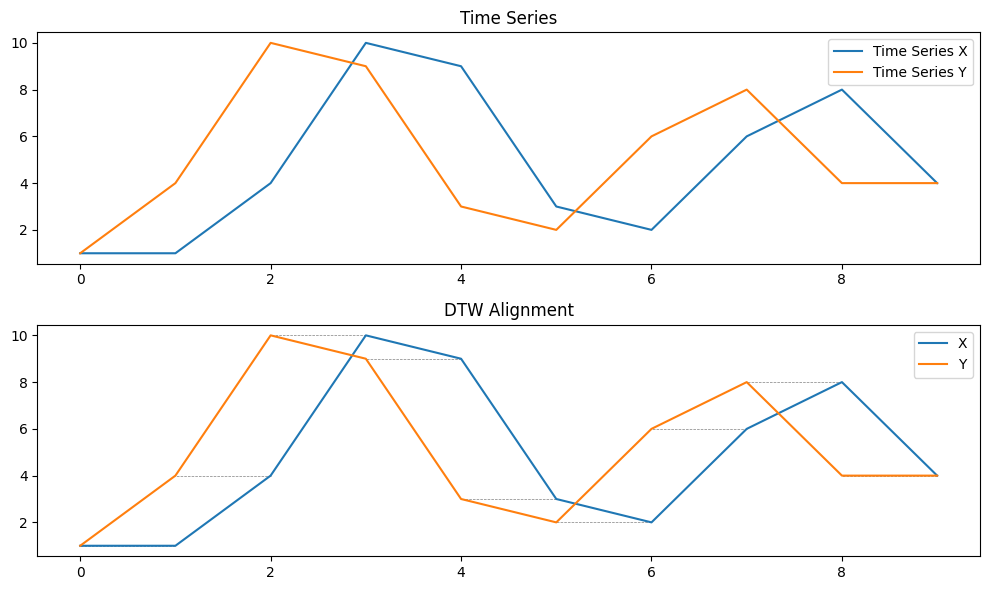

DTW Distance: 9.0
Alignment Path: [(0, 0), (1, 0), (2, 1), (3, 2), (4, 3), (5, 4), (6, 5), (7, 6), (8, 7), (9, 8), (9, 9)]


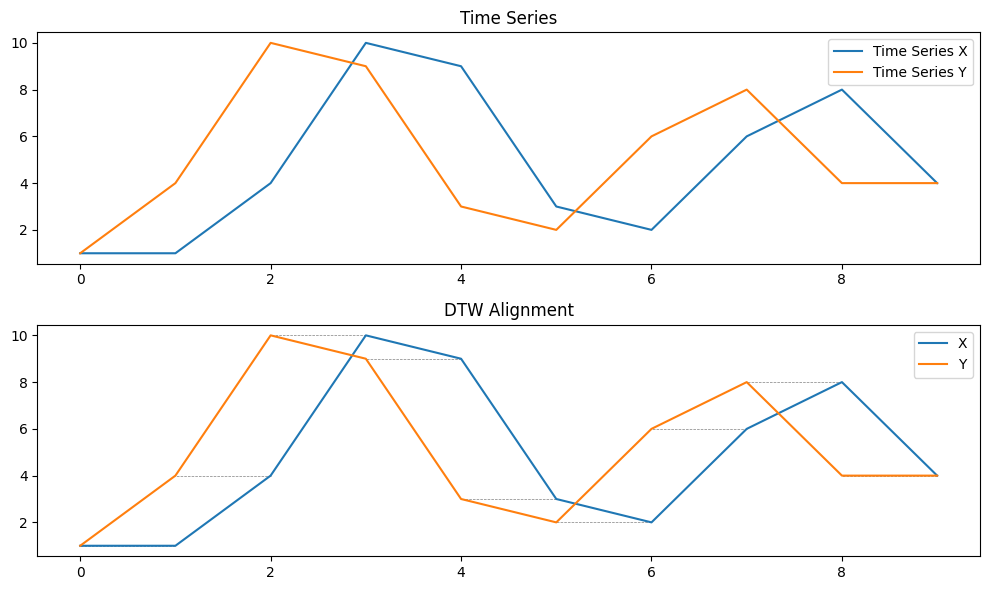

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean
from fastdtw import fastdtw

# Sample time series data
x = [1, 1, 4, 10, 9, 3, 2, 6, 8, 4]
y = [1, 4, 10, 9, 3, 2, 6, 8, 4, 4]

# Convert the series into the required format (list of tuples)
x = [(i, value) for i, value in enumerate(x)]
y = [(i, value) for i, value in enumerate(y)]

# Compute DTW distance and alignment path
distance, path = fastdtw(x, y, dist=euclidean)

print("DTW Distance:", distance)
print("Alignment Path:", path)

# Plot the alignment
plt.figure(figsize=(10, 6))

# Original time series plot
plt.subplot(2, 1, 1)
plt.plot([value for _, value in x], label='Time Series X')
plt.plot([value for _, value in y], label='Time Series Y')
plt.title('Time Series')
plt.legend()

# DTW alignment plot
plt.subplot(2, 1, 2)
for (map_x, map_y) in path:
    plt.plot([map_x, map_y], [x[map_x][1], y[map_y][1]], color='gray', linestyle='--', linewidth=0.5)
plt.plot([value for _, value in x], label='X')
plt.plot([value for _, value in y], label='Y')
plt.title('DTW Alignment')
plt.legend()

plt.tight_layout()
plt.show()

DTW Distance (D): 0.0


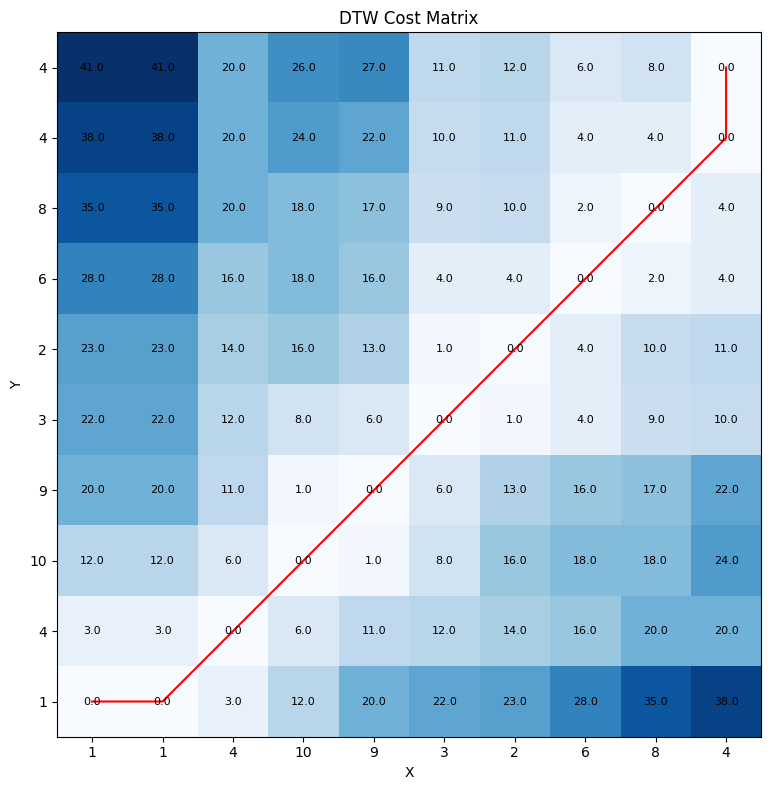

In [10]:
import numpy as np
import matplotlib.pyplot as plt

x = [1, 1, 4, 10, 9, 3, 2, 6, 8, 4] 
y = [1, 4, 10, 9, 3, 2, 6, 8, 4, 4]  

n, m = len(y), len(x)
dtw = np.zeros((n, m))

dtw[0, 0] = abs(y[0] - x[0])

for i in range(1, n):
    dtw[i, 0] = abs(y[i] - x[0]) + dtw[i-1, 0]

for j in range(1, m):
    dtw[0, j] = abs(y[0] - x[j]) + dtw[0, j-1]

for i in range(1, n):
    for j in range(1, m):
        cost = abs(y[i] - x[j])
        dtw[i, j] = cost + min(dtw[i-1, j],dtw[i, j-1],dtw[i-1, j-1] )

dtw_distance = dtw[-1, -1]
print("DTW Distance (D):", dtw_distance)

i, j = n - 1, m - 1
path = [(i, j)]
while i > 0 or j > 0:
    if i == 0:
        j -= 1
    elif j == 0:
        i -= 1
    else:
        steps = [(dtw[i-1, j-1], i-1, j-1), (dtw[i-1, j], i-1, j),(dtw[i, j-1], i, j-1)]
        _, i, j = min(steps)
    path.append((i, j))
path = np.array(path)

dtw_flipped = np.flipud(dtw)

plt.figure(figsize=(10, 8))
plt.imshow(dtw_flipped, cmap='Blues', interpolation='nearest')
# plt.colorbar(label='Cumulative Cost')
plt.title("DTW Cost Matrix")

plt.xticks(ticks=np.arange(m), labels=x)
plt.yticks(ticks=np.arange(n), labels=reversed(y))  # Flip y-axis labels to match flip

for i in range(n):
    for j in range(m):
        cost_val = round(dtw[i, j], 1)
        plt.text(j, n - 1 - i, str(cost_val), ha='center', va='center', color='black', fontsize=8)

flipped_path = [(n - 1 - i, j) for i, j in path]
flipped_path = np.array(flipped_path)
plt.plot(flipped_path[:, 1], flipped_path[:, 0], 'r')  # path in red

plt.xlabel("X")
plt.ylabel("Y")
plt.tight_layout()
plt.show()

Missing values in TSLA series: 0
Missing values in AMZN series: 0
DTW distance between TSLA and AMZN: 1773.233482585784
Dissimilarity between TSLA and AMZN 7.092933930343136


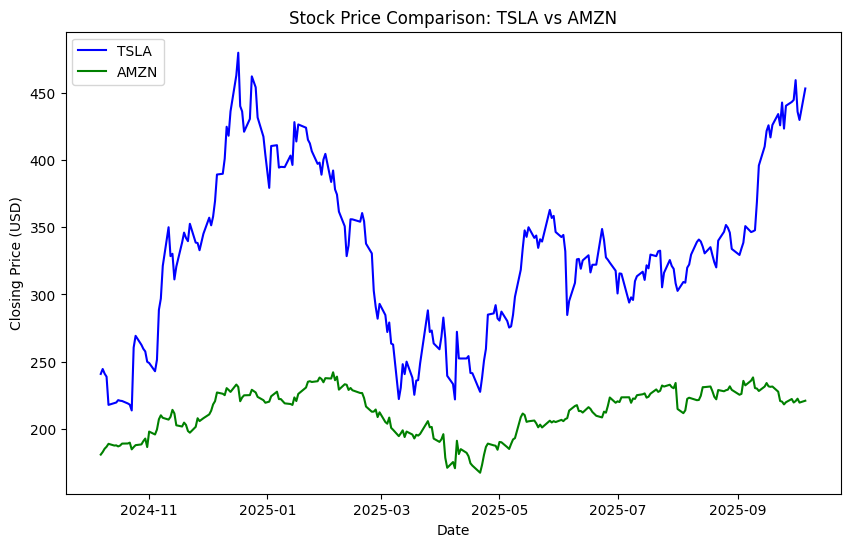

In [6]:
import yfinance as yf
import pandas as pd
from dtaidistance import dtw
ticker_1 = yf.Ticker("TSLA")
ticker_2 = yf.Ticker("AMZN")

data_1 = ticker_1.history(period="1y")
data_2 = ticker_2.history(period="1y")

series_1 = data_1['Close'].values
series_2 = data_2['Close'].values
print("Missing values in TSLA series:", np.isnan(series_1).sum())
print("Missing values in AMZN series:", np.isnan(series_2).sum())

series_1 = pd.Series(series_1).ffill().values
series_2 = pd.Series(series_2).ffill().values

min_length = min(len(series_1), len(series_2))
series_1 = series_1[:min_length]
series_2 = series_2[:min_length]
distance = dtw.distance(series_1, series_2)
print(f"DTW distance between TSLA and AMZN: {distance}")
print(f"Dissimilarity between TSLA and AMZN {distance/min_length}")
plt.figure(figsize=(10, 6))
plt.plot(data_1.index[:min_length], series_1, label="TSLA", color="blue")
plt.plot(data_2.index[:min_length], series_2, label="AMZN", color="green")
plt.title("Stock Price Comparison: TSLA vs AMZN")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.show()


DTW Distance (D): 21.0


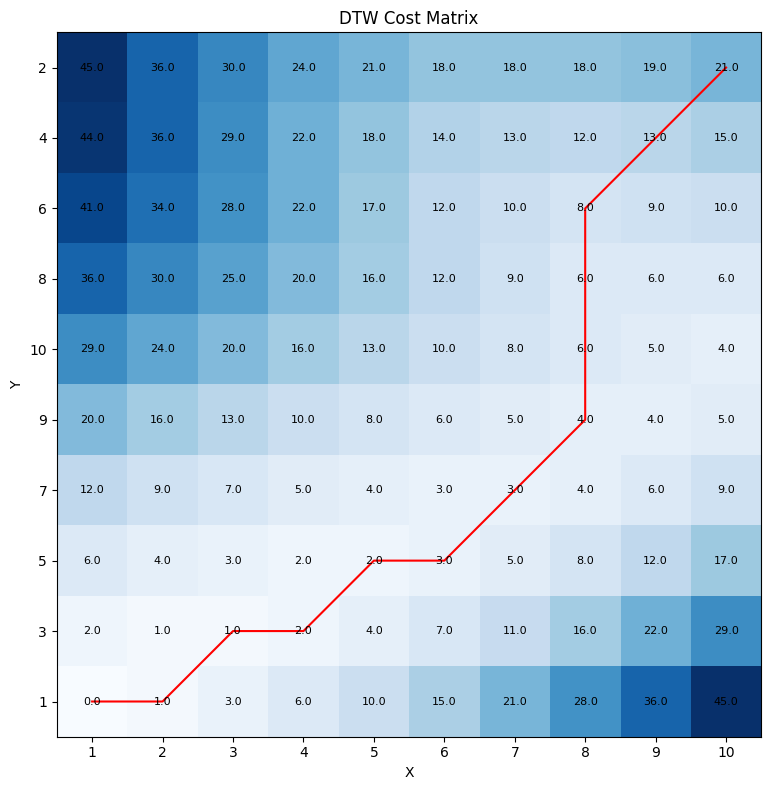

In [2]:

x = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
y = [1, 3, 5, 7, 9, 10, 8, 6, 4, 2] 

n, m = len(y), len(x)
dtw = np.zeros((n, m))

dtw[0, 0] = abs(y[0] - x[0])

for i in range(1, n):
    dtw[i, 0] = abs(y[i] - x[0]) + dtw[i-1, 0]

for j in range(1, m):
    dtw[0, j] = abs(y[0] - x[j]) + dtw[0, j-1]

for i in range(1, n):
    for j in range(1, m):
        cost = abs(y[i] - x[j])
        dtw[i, j] = cost + min(dtw[i-1, j],dtw[i, j-1],dtw[i-1, j-1] )

dtw_distance = dtw[-1, -1]
print("DTW Distance (D):", dtw_distance)

i, j = n - 1, m - 1
path = [(i, j)]
while i > 0 or j > 0:
    if i == 0:
        j -= 1
    elif j == 0:
        i -= 1
    else:
        steps = [(dtw[i-1, j-1], i-1, j-1), (dtw[i-1, j], i-1, j),(dtw[i, j-1], i, j-1)]
        _, i, j = min(steps)
    path.append((i, j))
path = np.array(path)

dtw_flipped = np.flipud(dtw)

plt.figure(figsize=(10, 8))
plt.imshow(dtw_flipped, cmap='Blues', interpolation='nearest')
# plt.colorbar(label='Cumulative Cost')
plt.title("DTW Cost Matrix")

plt.xticks(ticks=np.arange(m), labels=x)
plt.yticks(ticks=np.arange(n), labels=reversed(y))  # Flip y-axis labels to match flip

for i in range(n):
    for j in range(m):
        cost_val = round(dtw[i, j], 1)
        plt.text(j, n - 1 - i, str(cost_val), ha='center', va='center', color='black', fontsize=8)

flipped_path = [(n - 1 - i, j) for i, j in path]
flipped_path = np.array(flipped_path)
plt.plot(flipped_path[:, 1], flipped_path[:, 0], 'r')  # path in red

plt.xlabel("X")
plt.ylabel("Y")
plt.tight_layout()
plt.show()